In [ ]:
import pandas as pd
from plotnine import aes, geom_path, ggplot, labs

In [ ]:
troops = pd.read_csv("minard-troops.txt", sep="\t", engine="python")
cities = pd.read_csv("minard-cities.txt", sep="  ", engine="python")

In [4]:
troops.head(5)

,ID,long,lat,survivors,direction,group,date,temperature (C)
0,1,24.0,54.9,340000,A,1,1812-06-24,NaN
1,2,24.5,55.0,340000,A,1,1812-06-29,NaN
2,3,25.5,54.5,340000,A,1,1812-07-03,NaN
3,4,26.0,54.7,320000,A,1,1812-07-07,NaN
4,5,27.0,54.8,300000,A,1,1812-07-11,NaN


In [ ]:
first_plot = plotnine.ggplot(troops, aes("long", "lat")) + plotnine.geom_point()

In [ ]:
second_plot = (
    ggplot(troops, aes(x="long", y="survivors"))
    + geom_path()
    + labs(title="Survivors Path")
)


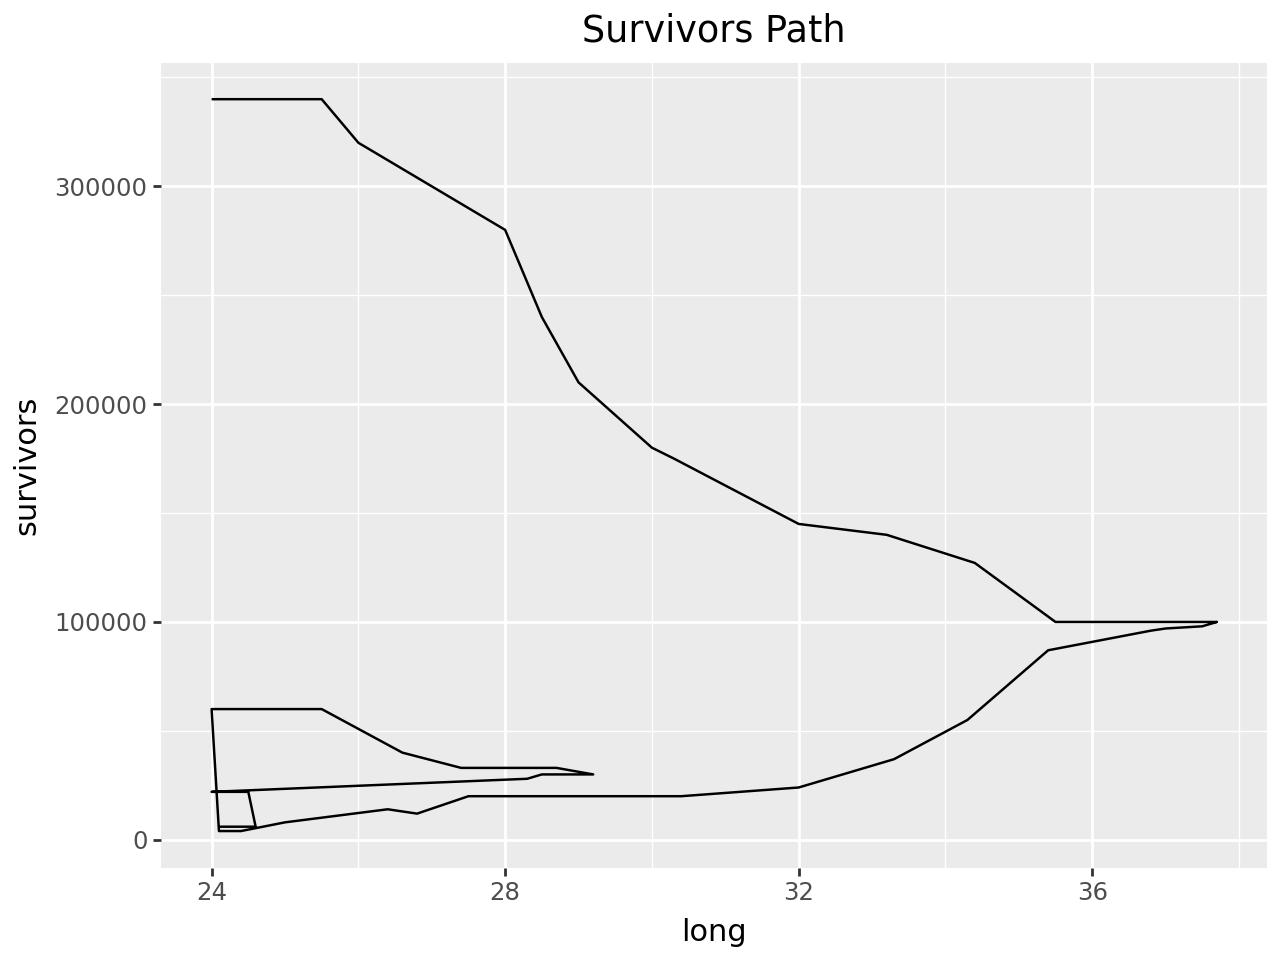

In [16]:
second_plot

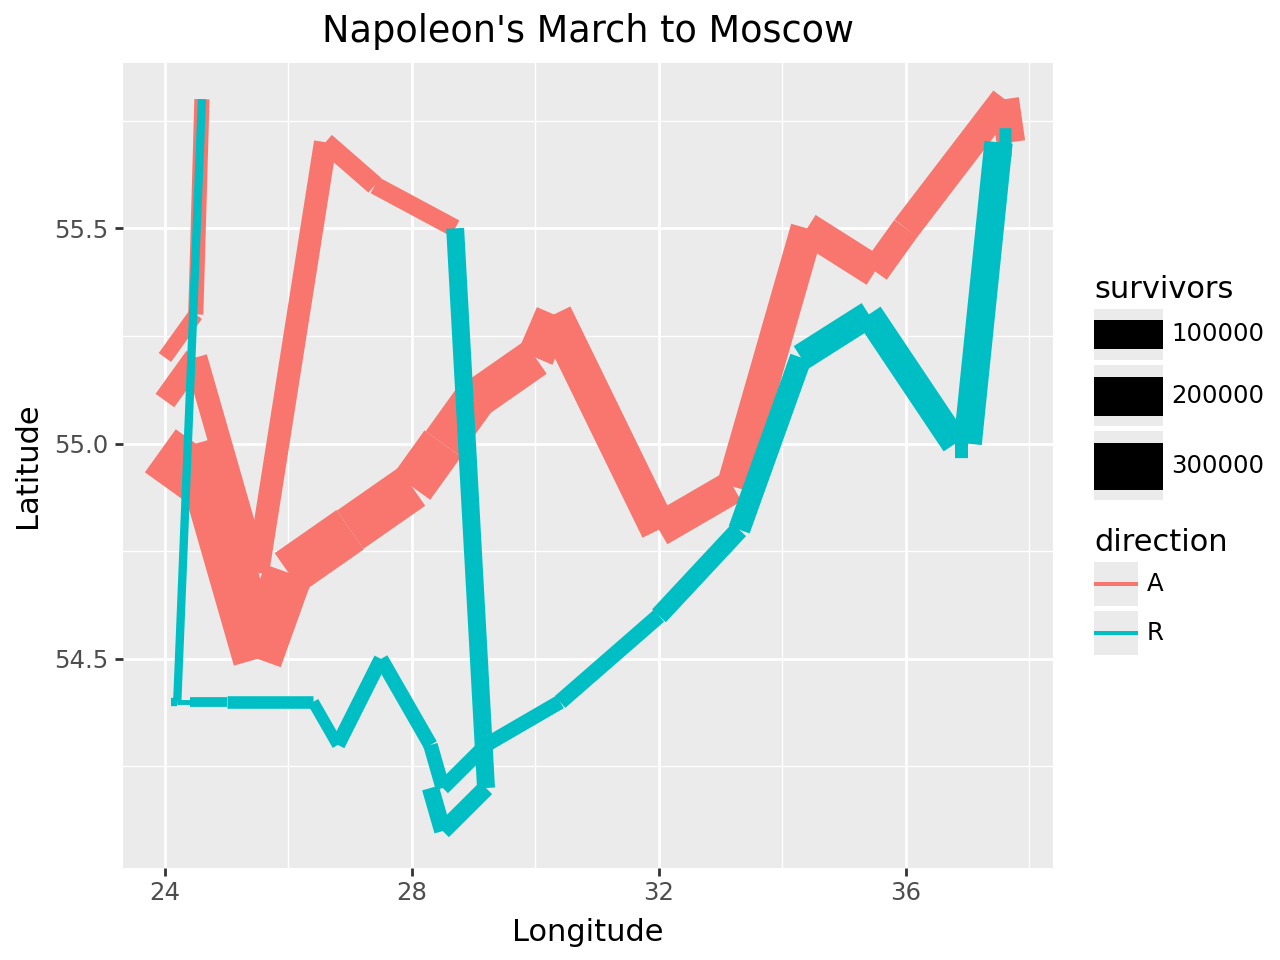

In [ ]:
map_plot = (
    plotnine.ggplot(troops, aes(x="long", y="lat"))
    + plotnine.geom_path(aes(size="survivors", color="direction", group="group"))
    + plotnine.scale_size(range=(1, 10))  # 调整线条粗细范围
    + plotnine.labs(title="Napoleon's March to Moscow", x="Longitude", y="Latitude")
)

map_plot

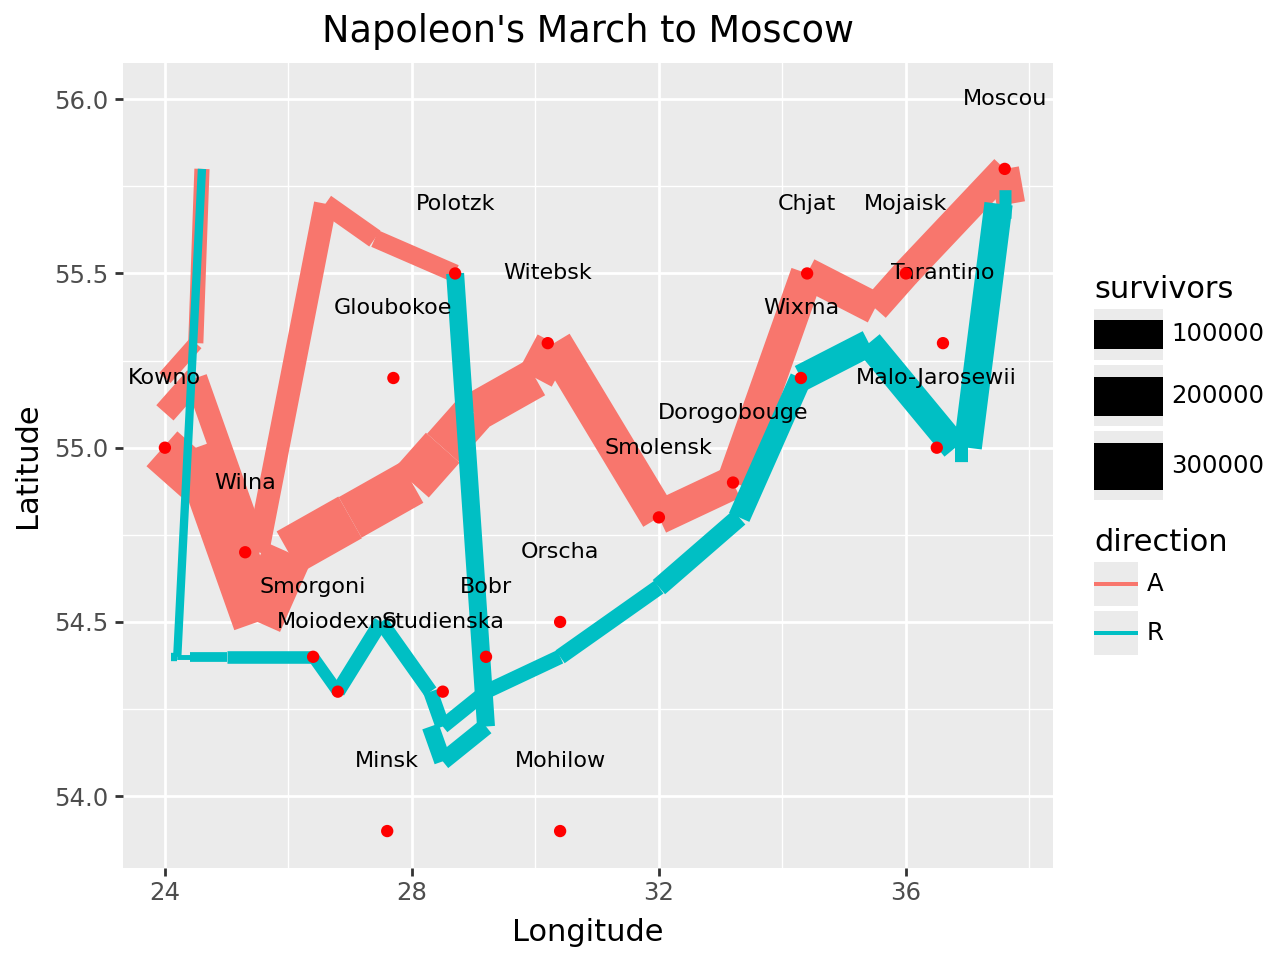

In [ ]:
# 假设城市数据框叫 cities
map_with_cities = (
    map_plot
    + plotnine.geom_text(aes(label="city"), data=cities, size=8, nudge_y=0.2)
    + plotnine.geom_point(data=cities, color="red")  # 标出城市点
)

map_with_cities

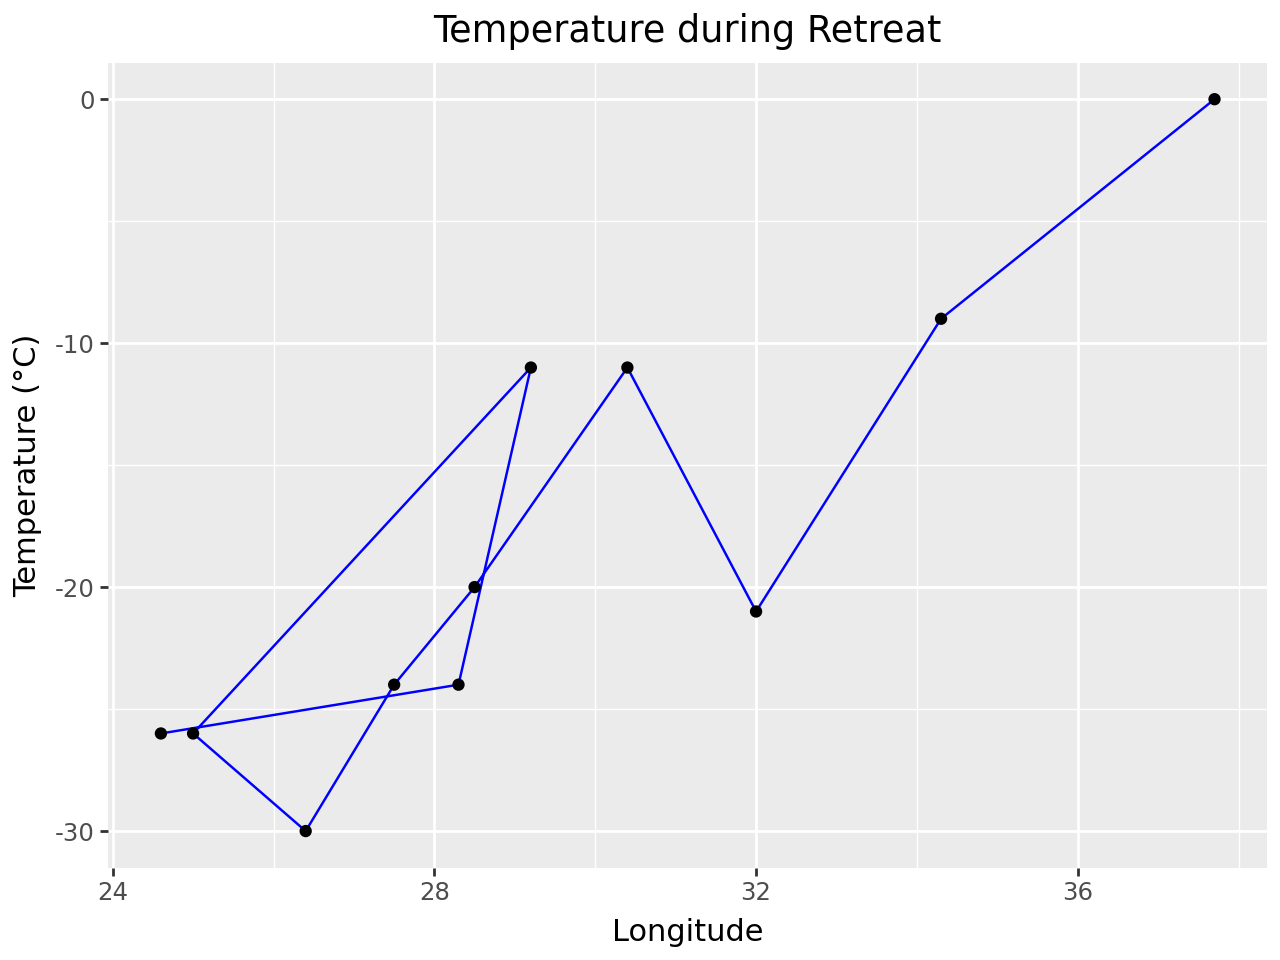

In [ ]:
# 过滤出有温度数据的行（通常是撤退阶段）
retreat_data = troops.dropna(subset=["temperature (C)"])

temp_plot = (
    plotnine.ggplot(retreat_data, aes(x="long", y="temperature (C)"))
    + plotnine.geom_path(color="blue")
    + plotnine.geom_point()
    + plotnine.labs(
        title="Temperature during Retreat", x="Longitude", y="Temperature (°C)"
    )
)

temp_plot

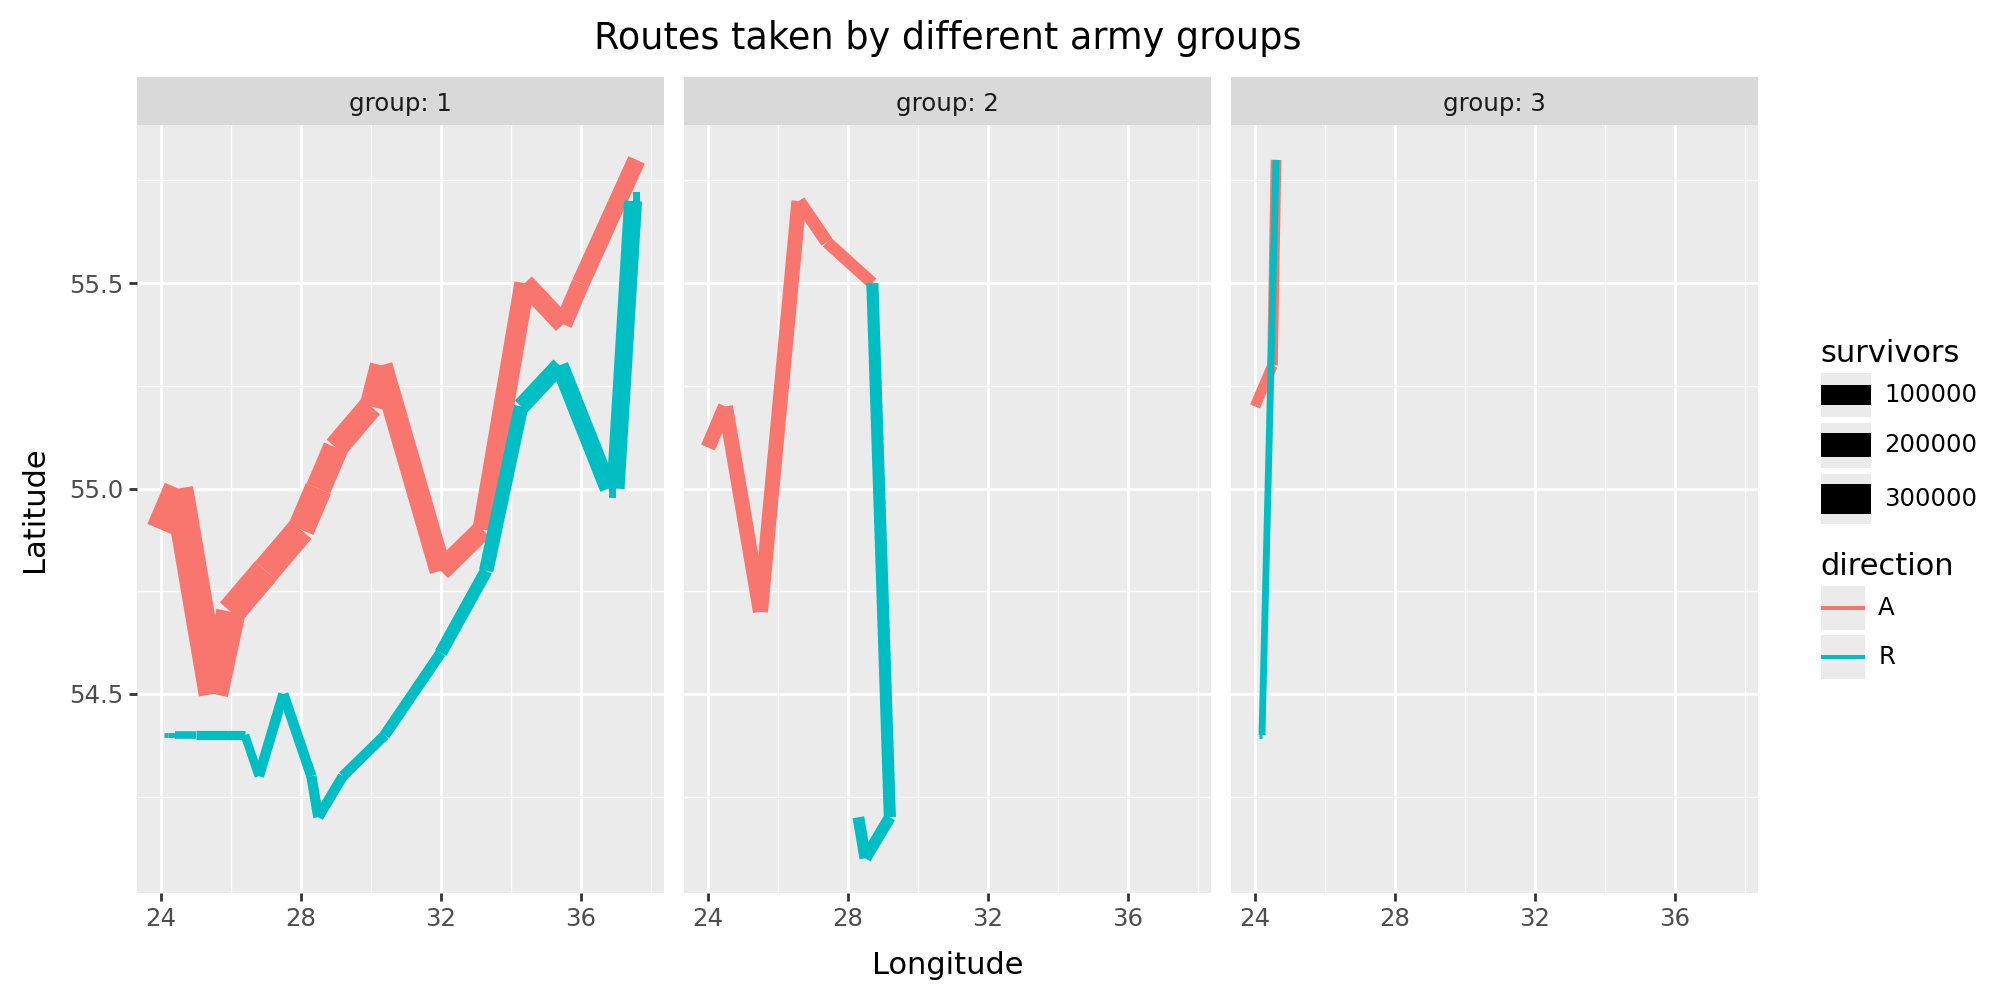

In [ ]:
facet_group_plot = (
    plotnine.ggplot(troops, aes(x="long", y="lat"))
    # 用颜色区分进军和撤退，用粗细表示人数
    + plotnine.geom_path(aes(size="survivors", color="direction"))
    # 关键：按 group 分面显示
    + plotnine.facet_wrap("~group", labeller="label_both")
    + plotnine.labs(
        title="Routes taken by different army groups", x="Longitude", y="Latitude"
    )
    + plotnine.theme(figure_size=(10, 5))  # 调整画布大小以适应分面
)

facet_group_plot


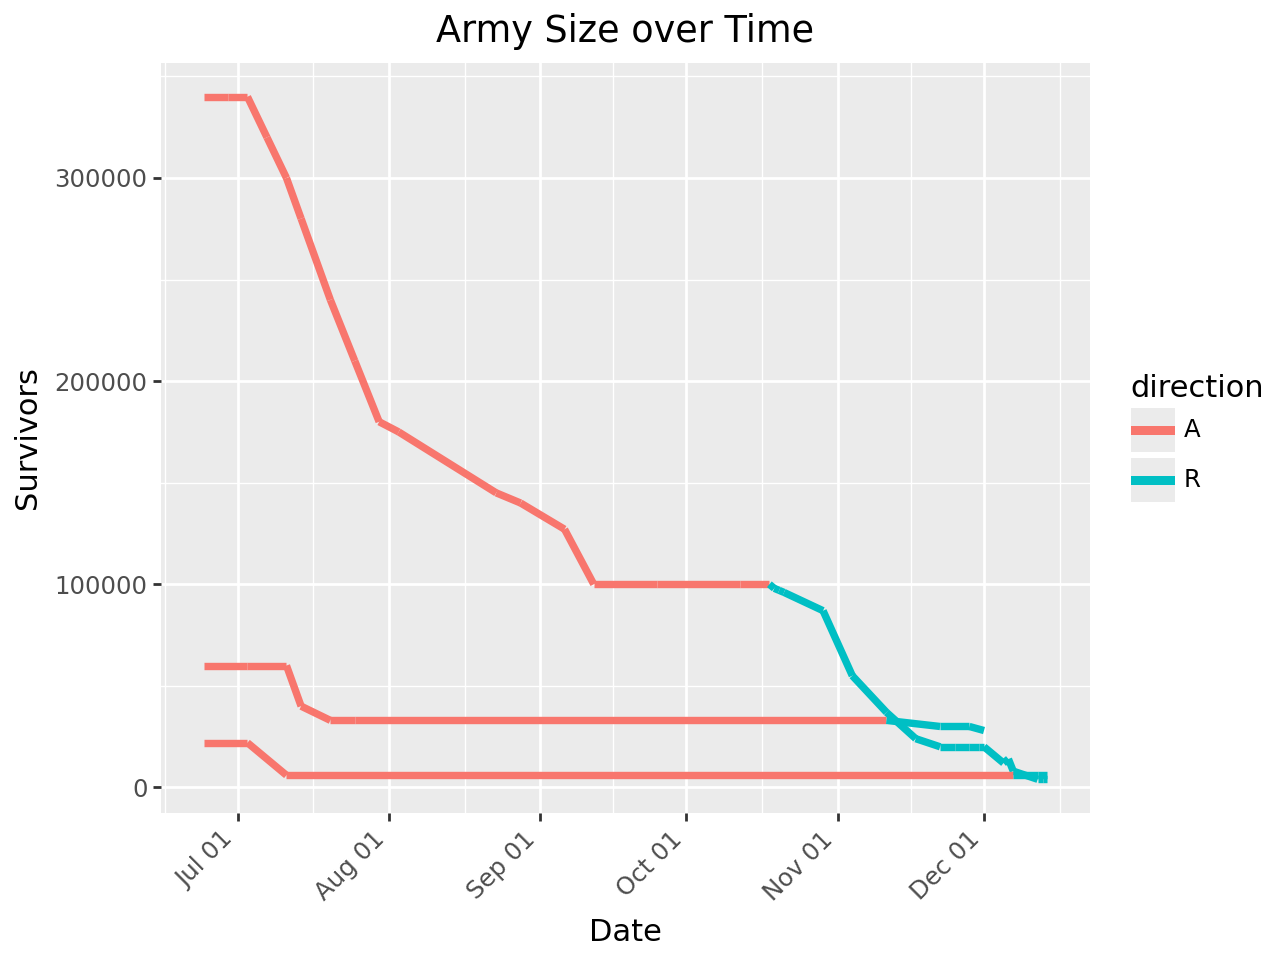

In [ ]:
import pandas as pd
from plotnine import *

time_plot = (
    ggplot(troops, aes(x="date", y="survivors", group="group"))
    + geom_path(aes(color="direction"), size=1.5)
    # --- 核心修改部分开始 ---
    + scale_x_date(
        date_breaks="1 month",  # 设置间隔：每1个月显示一个刻度 (可选 "2 weeks", "10 days" 等)
        date_labels="%b %d",  # 设置格式：例如 "Jun 24" (%b=月份缩写, %m=数字月份)
    )
    + theme(
        axis_text_x=element_text(rotation=45, hjust=1)  # 旋转45度，并调整对齐方式
    )
    # --- 核心修改部分结束 ---
    + labs(title="Army Size over Time", x="Date", y="Survivors")
)

time_plot